# Frequency-Domain Filtering for Artifact Removal

### E/21/087 - Dewagedara D.M.E.S.

### Task 1 — Visualize the Frequency Spectrum 

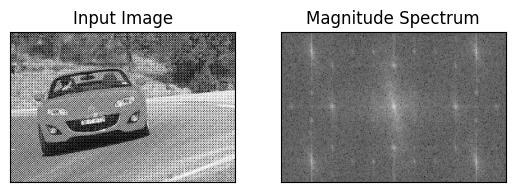

In [9]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

# Read image as grayscale
img = cv.imread('car.jpg', 0)

# Compute FFT
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)

# Magnitude spectrum (safe version)
magnitude_spectrum = 20 * np.log1p(np.abs(fshift))

# Display
plt.subplot(121)
plt.imshow(img, cmap='gray')
plt.title('Input Image')
plt.xticks([])
plt.yticks([])

plt.subplot(122)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Magnitude Spectrum')
plt.xticks([])
plt.yticks([])

plt.show()

### Answer -

After applying the 2D FFT and shifting the zero-frequency component to the center, the magnitude spectrum shows how image information is distributed across frequencies. The bright central region represents low-frequency components, which contain the overall structure and large shapes of the image (such as the car and background). The scattered bright points away from the center represent high-frequency components, including edges, textures, and the periodic halftone pattern. These periodic noise patterns are easier to identify in the frequency domain than in the spatial domain.

### Task 2 — Design Mask, Filter, and Reconstruct 

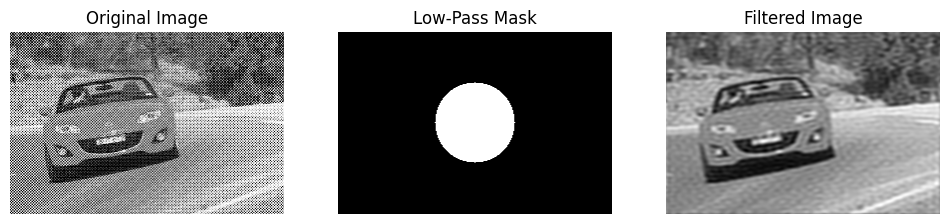

In [10]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load grayscale image
img = cv.imread('car.jpg', 0)

# FFT
F = np.fft.fft2(img)
F_shift = np.fft.fftshift(F)

rows, cols = img.shape
crow, ccol = rows//2, cols//2

# Create Low-Pass Mask
def create_lowpass_mask(shape, radius):
    rows, cols = shape
    center_r, center_c = rows//2, cols//2
    
    mask = np.zeros((rows, cols), dtype=np.float32)
    
    for i in range(rows):
        for j in range(cols):
            distance = np.sqrt((i-center_r)**2 + (j-center_c)**2)
            if distance <= radius:
                mask[i, j] = 1
    return mask

R = 40   # radius 
mask = create_lowpass_mask(img.shape, R)

# Apply Mask
F_filt = F_shift * mask

# Inverse FFT
F_ishift = np.fft.ifftshift(F_filt)
clean = np.fft.ifft2(F_ishift)
clean = np.abs(clean)

# Display Results
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("Low-Pass Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(clean, cmap='gray')
plt.title("Filtered Image")
plt.axis("off")

plt.show()

### Answer -

#### 1. Explanation of Frequency Components Removed

A low-pass filter was applied in the frequency domain by creating a circular mask centered at the origin of the shifted FFT. This mask keeps only the low-frequency components (central region) and removes most high-frequency components located farther from the center.

The removed components correspond mainly to:

- Halftone periodic noise

- Fine textures

- Sharp edges

These high-frequency components are responsible for rapid intensity variations in the image.

#### 2. Effect on Visible Pattern Noise

After applying the low-pass mask and reconstructing the image using inverse FFT:

- The repetitive halftone dot pattern is significantly reduced because it exists in high-frequency bands.

- The image appears smoother since many rapid intensity variations were removed

#### 3. Visual Details Lost or Preserved

Preserved

- Overall structure of the car

- Large shapes and major regions

Lost

- Fine edges

- Small textures

- Some sharp boundary details

This happens because edges also contain high-frequency information, which is partially removed by the low-pass filter.



### Final Reflection

Frequency-domain analysis complements spatial filtering because it reveals how image information is distributed across different frequencies, making it easier to identify structured or periodic noise that may not be obvious in the spatial domain. While spatial filtering operates directly on pixel values using local neighborhoods (e.g., smoothing or edge filters), frequency-domain filtering allows selective removal of specific frequency components, such as repetitive patterns or periodic artifacts, by modifying their locations in the spectrum. Frequency-domain methods are preferred when noise is periodic or structured (such as halftone patterns or interference), since these appear as distinct peaks that can be removed effectively using filters like low-pass or notch filters. In contrast, spatial filtering is preferred for random noise reduction or general image enhancement because it is simpler, faster, and easier to implement without requiring transformations like the Fast Fourier Transform (FFT).